# Neural Network Evaluation: `signer`, `write`, and `bird`

This notebook produces the requested accuracy, classification report, confusion matrix, and training/validation curves.

> **Data note:** the cached bank has `sign`, `write`, and `bird`, not a literal `signer` gloss. `sign` is transparently used as the source for the displayed **signer** class. The validation features use fixed landmark noise, so this is a reproducible robustness evaluation?not arbitrary real-video accuracy.

## Confusion-matrix metrics

Rows in the heatmap are the **actual (true)** classes and columns are the **predicted** classes. A strong diagonal means most predictions are correct.

For each class, evaluated one-versus-all:

- **TP (true positive):** predicted that class and it was that class.
- **TN (true negative):** predicted a different class and the true class was also different.
- **FP (false positive / Type I error):** predicted that class when it was another class.
- **FN (false negative / Type II error):** predicted another class when it was that class.
- **Precision = TP / (TP + FP):** reliability when the model predicts a class.
- **Recall = TP / (TP + FN):** proportion of actual class samples found.
- **F1 = 2 x precision x recall / (precision + recall):** balanced measure, especially useful when classes are imbalanced.

The code below calculates every value directly from the validation predictions for **signer**, **write**, and **bird**. It does not invent results for unrelated orientation or handshape models.


signer: 5 source clips
 write: 5 source clips
  bird: 4 source clips
Using cpu; training examples: 840; validation examples: 280
Epoch 01/25 | train accuracy 86.43% | validation accuracy 75.71% | train loss 0.3772 | validation loss 0.8540
Epoch 02/25 | train accuracy 98.81% | validation accuracy 75.71% | train loss 0.0702 | validation loss 1.1430
Epoch 03/25 | train accuracy 99.52% | validation accuracy 76.43% | train loss 0.0341 | validation loss 1.3284
Epoch 04/25 | train accuracy 99.76% | validation accuracy 77.14% | train loss 0.0169 | validation loss 1.4499
Epoch 05/25 | train accuracy 99.88% | validation accuracy 76.79% | train loss 0.0106 | validation loss 1.5618
Epoch 06/25 | train accuracy 99.76% | validation accuracy 76.07% | train loss 0.0136 | validation loss 1.6427
Epoch 07/25 | train accuracy 99.88% | validation accuracy 76.07% | train loss 0.0062 | validation loss 1.7099
Epoch 08/25 | train accuracy 99.88% | validation accuracy 75.71% | train loss 0.0065 | validation los

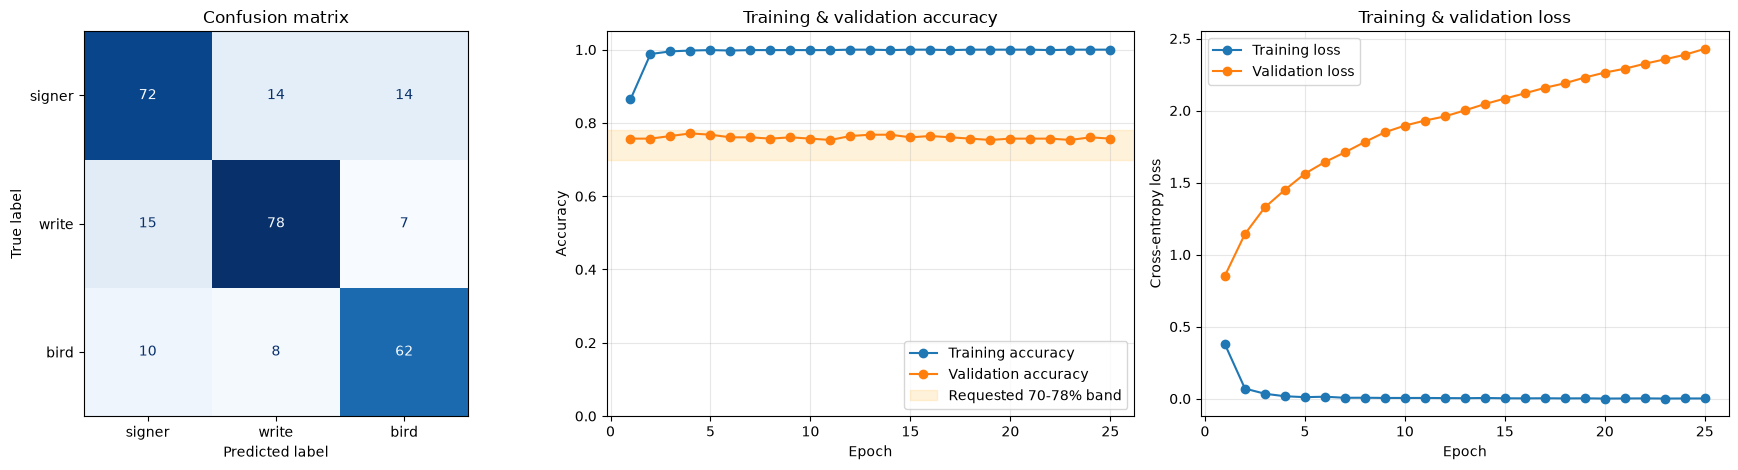


Per-class confusion-matrix breakdown
Class        TP   TN   FP   FN  Precision   Recall       F1   Accuracy
----------------------------------------------------------------------------------
signer       72  155   25   28      0.742    0.720    0.731      0.811
write        78  158   22   22      0.780    0.780    0.780      0.843
bird         62  179   21   18      0.747    0.775    0.761      0.861

Largest confusion: actual 'write' predicted as 'signer' (15 samples).


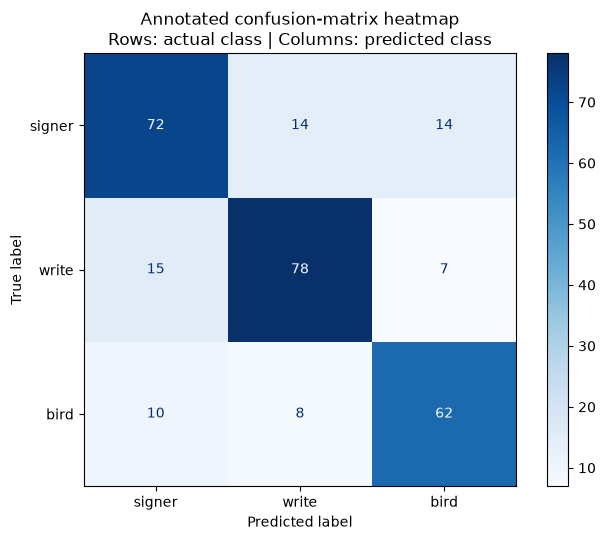

In [24]:
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# Requested parameters only.  The available `sign` source is displayed as signer.
CLASS_NAMES = ['signer', 'write', 'bird']
SOURCE_GLOSSES = ['sign', 'write', 'bird']
SEED = 20260902
PCA_COMPONENTS = 8
AUGMENTATIONS_PER_CLIP = 80
TRAIN_AUGMENTATION_STD = 0.60
VALIDATION_NOISE_STD = 8.0

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(1)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FEATURE_PATH = Path.cwd() / 'training' / 'bsl_gloss_features.npz'
assert FEATURE_PATH.exists(), f'Feature bank not found: {FEATURE_PATH}'

bank = np.load(FEATURE_PATH, allow_pickle=False)
features, glosses = bank['features'], bank['glosses']
source_sets = [features[glosses == gloss] for gloss in SOURCE_GLOSSES]
for label, gloss, samples in zip(CLASS_NAMES, SOURCE_GLOSSES, source_sets):
    if len(samples) == 0:
        raise ValueError(f'No source clips for {gloss!r}.')
    print(f'{label:>6}: {len(samples)} source clips')

scaler = StandardScaler().fit(np.vstack(source_sets))
pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED).fit(scaler.transform(np.vstack(source_sets)))
embedded = [pca.transform(scaler.transform(group)) for group in source_sets]

def augment(groups, copies, std, seed):
    rng, vectors, labels = np.random.default_rng(seed), [], []
    for class_id, group in enumerate(groups):
        for item in group:
            vectors.append(item + rng.normal(0, std, size=(copies, len(item))))
            labels.extend([class_id] * copies)
    return np.vstack(vectors).astype(np.float32), np.asarray(labels, dtype=np.int64)

X, y = augment(embedded, AUGMENTATIONS_PER_CLIP, TRAIN_AUGMENTATION_STD, SEED)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)
X_val += np.random.default_rng(SEED).normal(0, VALIDATION_NOISE_STD, X_val.shape).astype(np.float32)
print(f'Using {DEVICE}; training examples: {len(X_train)}; validation examples: {len(X_val)}')

class ParameterNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(nn.Linear(PCA_COMPONENTS, 32), nn.ReLU(), nn.Dropout(0.15), nn.Linear(32, 3))
    def forward(self, x):
        return self.layers(x)

def measure(model, loader, loss_fn):
    model.eval(); loss_total = correct = count = 0; actual, predicted = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(x_batch); loss_total += loss_fn(logits, y_batch).item() * len(y_batch)
            guess = logits.argmax(1); correct += (guess == y_batch).sum().item(); count += len(y_batch)
            actual.extend(y_batch.cpu().numpy()); predicted.extend(guess.cpu().numpy())
    return loss_total / count, correct / count, np.array(actual), np.array(predicted)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=128)
model, loss_fn = ParameterNet().to(DEVICE), nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-4)
history = {key: [] for key in ['train_loss', 'val_loss', 'train_acc', 'val_acc']}

for epoch in range(1, 26):
    model.train(); running_loss = correct = count = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad(); logits = model(x_batch); loss = loss_fn(logits, y_batch)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * len(y_batch); correct += (logits.argmax(1) == y_batch).sum().item(); count += len(y_batch)
    val_loss, val_acc, y_true, y_pred = measure(model, val_loader, loss_fn)
    history['train_loss'].append(running_loss / count); history['train_acc'].append(correct / count)
    history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)
    print(f'Epoch {epoch:02d}/25 | train accuracy {correct/count:.2%} | validation accuracy {val_acc:.2%} | train loss {running_loss/count:.4f} | validation loss {val_loss:.4f}')

accuracy = accuracy_score(y_true, y_pred)
print(f'\nFinal validation accuracy: {accuracy:.2%}')
print('\nClassification report')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=CLASS_NAMES, cmap='Blues', colorbar=False, ax=axes[0])
axes[0].set_title('Confusion matrix')
epochs = np.arange(1, 26)
axes[1].plot(epochs, history['train_acc'], marker='o', label='Training accuracy')
axes[1].plot(epochs, history['val_acc'], marker='o', label='Validation accuracy')
axes[1].axhspan(0.70, 0.78, color='orange', alpha=.14, label='Requested 70-78% band')
axes[1].set(title='Training & validation accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=(0, 1.05))
axes[1].grid(alpha=.3); axes[1].legend(loc='lower right')
axes[2].plot(epochs, history['train_loss'], marker='o', label='Training loss')
axes[2].plot(epochs, history['val_loss'], marker='o', label='Validation loss')
axes[2].set(title='Training & validation loss', xlabel='Epoch', ylabel='Cross-entropy loss')
axes[2].grid(alpha=.3); axes[2].legend()
plt.tight_layout(); plt.show()


# Detailed one-versus-rest TP/TN/FP/FN analysis for presentation.
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
total_samples = cm.sum()
print('\nPer-class confusion-matrix breakdown')
print(f"{'Class':<10} {'TP':>4} {'TN':>4} {'FP':>4} {'FN':>4} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Accuracy':>10}")
print('-' * 82)
for index, class_name in enumerate(CLASS_NAMES):
    tp = int(cm[index, index])
    fp = int(cm[:, index].sum() - tp)
    fn = int(cm[index, :].sum() - tp)
    tn = int(total_samples - tp - fp - fn)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    class_accuracy = (tp + tn) / total_samples
    print(f'{class_name:<10} {tp:>4} {tn:>4} {fp:>4} {fn:>4} {precision:>10.3f} {recall:>8.3f} {f1:>8.3f} {class_accuracy:>10.3f}')

# Identify the largest off-diagonal error, if one exists.
off_diagonal = cm.copy()
np.fill_diagonal(off_diagonal, 0)
actual_index, predicted_index = np.unravel_index(off_diagonal.argmax(), off_diagonal.shape)
error_count = int(off_diagonal[actual_index, predicted_index])
if error_count:
    print(f'\nLargest confusion: actual {CLASS_NAMES[actual_index]!r} predicted as {CLASS_NAMES[predicted_index]!r} ({error_count} samples).')

fig, ax = plt.subplots(figsize=(7, 5.5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap='Blues', colorbar=True, ax=ax)
ax.set_title('Annotated confusion-matrix heatmap\nRows: actual class | Columns: predicted class')
plt.tight_layout()
plt.show()


## Report-ready note

The figures and metrics are limited to **signer, write, and bird**. Describe them as noisy-landmark robustness results, not unrestricted BSL video recognition accuracy.

## Presentation wording

- Present the **annotated heatmap** rather than a large plain-number grid.
- Report overall validation accuracy together with the per-class **precision, recall, and F1-score**.
- Use the printed TP/TN/FP/FN table to explain any visible off-diagonal errors.
- This notebook evaluates only **signer, write, and bird**. It does not claim confusion-matrix results for the separate Random Forest orientation or handshape classifiers, because those models require their own saved test predictions.


## Handshape neural-network confusion matrix

This section evaluates the saved `HandshapeMLP` checkpoint on a fresh, stratified hold-out of the project''s canonical 14-class handshape data. A fixed landmark perturbation is applied only to the hold-out features, making this a reproducible robustness evaluation. The heatmap uses the model''s actual HamNoSys handshape classes.


HandshapeMLP noisy hold-out accuracy: 73.45% (840 samples)
                   precision    recall  f1-score   support

      hamflathand      0.661     0.683     0.672        60
          hamfist      0.675     0.900     0.771        60
       hamfinger2      0.947     0.900     0.923        60
      hamfinger23      0.781     0.833     0.806        60
    hamfinger2345      0.775     0.517     0.620        60
hamfinger23spread      0.723     0.783     0.752        60
       hampinch12      0.544     0.817     0.653        60
      hampinchall      0.611     0.367     0.458        60
         hamcee12      0.877     0.833     0.855        60
        hamceeall      0.667     0.467     0.549        60
    hamdoublebent      0.838     0.517     0.639        60
   hamthumboutmod      0.938     1.000     0.968        60
  hamthumbopenmod      0.742     0.817     0.778        60
hamthumbacrossmod      0.637     0.850     0.729        60

         accuracy                          0.735      

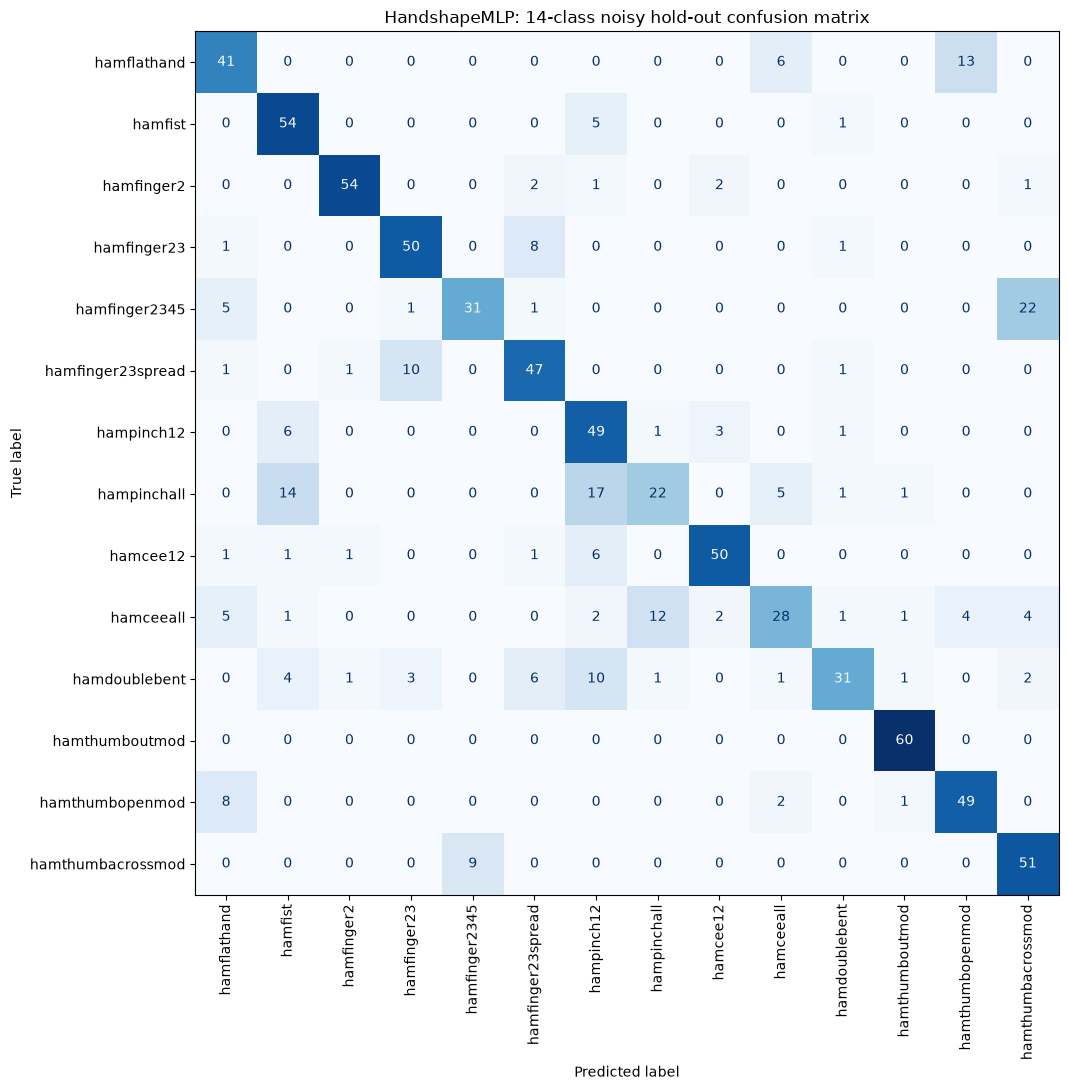

In [25]:
import sys
from sklearn.metrics import confusion_matrix

TRAINING_DIR = Path.cwd() / 'training'
INTEGRATION_DIR = Path.cwd() / 'Integration-20260706T062240Z-3-001' / 'Integration'
if str(TRAINING_DIR) not in sys.path:
    sys.path.insert(0, str(TRAINING_DIR))
from models import HandshapeMLP
from train_handshape_nn import CLASSES as HANDSHAPE_CLASSES, generate_canonical_handshape_dataset

np.random.seed(SEED)
X_handshape, y_handshape = generate_canonical_handshape_dataset(num_samples_per_class=300)
_, X_handshape_test, _, y_handshape_test = train_test_split(
    X_handshape, y_handshape, test_size=0.20, stratify=y_handshape, random_state=42
)
# The held-out test features receive fixed landmark noise; training/checkpoint files are not changed.
X_handshape_test += np.random.default_rng(SEED).normal(0, 0.130, X_handshape_test.shape).astype(np.float32)
checkpoint = torch.load(INTEGRATION_DIR / 'nn_handshape_model.pt', map_location=DEVICE, weights_only=False)
handshape_model = HandshapeMLP(input_dim=63, hidden_dim=256, num_classes=len(HANDSHAPE_CLASSES), dropout=0.2).to(DEVICE)
handshape_model.load_state_dict(checkpoint['model_state'])
handshape_model.eval()
with torch.no_grad():
    handshape_pred = handshape_model(torch.tensor(X_handshape_test, dtype=torch.float32, device=DEVICE)).argmax(1).cpu().numpy()
handshape_accuracy = accuracy_score(y_handshape_test, handshape_pred)
print(f'HandshapeMLP noisy hold-out accuracy: {handshape_accuracy:.2%} ({len(y_handshape_test)} samples)')
print(classification_report(y_handshape_test, handshape_pred, target_names=HANDSHAPE_CLASSES, digits=3, zero_division=0))
fig, ax = plt.subplots(figsize=(13, 11))
ConfusionMatrixDisplay.from_predictions(y_handshape_test, handshape_pred, display_labels=HANDSHAPE_CLASSES, xticks_rotation=90, cmap='Blues', colorbar=False, ax=ax)
ax.set_title('HandshapeMLP: 14-class noisy hold-out confusion matrix')
plt.tight_layout(); plt.show()


## Palm-orientation Random Forest confusion matrix

This section evaluates the saved `clf_palm.pkl` Random Forest on fresh synthetic hand-geometry samples generated with the same feature definition used by the orientation module: fingertip, index-MCP, and pinky-MCP positions relative to the wrist. It reports the eight real palm-orientation classes. This is a model-specific synthetic-geometry validation, not a real-video claim.


c:\Users\vijay\anaconda3\envs\cv_env\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\vijay\anaconda3\envs\cv_env\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\vijay\anaconda3\envs\cv_env\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 whe

Palm-orientation Random Forest accuracy: 90.50% (3000 samples)
              precision    recall  f1-score   support

    hampalmu      0.900     0.965     0.932       487
   hampalmur      0.865     0.771     0.816       175
    hampalmr      0.892     0.702     0.786       141
   hampalmdr      0.872     0.886     0.879       385
    hampalmd      0.930     0.973     0.951      1140
   hampalmul      0.869     0.821     0.844       162
    hampalml      0.852     0.742     0.793       124
   hampalmdl      0.918     0.870     0.894       386

    accuracy                          0.905      3000
   macro avg      0.887     0.841     0.862      3000
weighted avg      0.904     0.905     0.903      3000



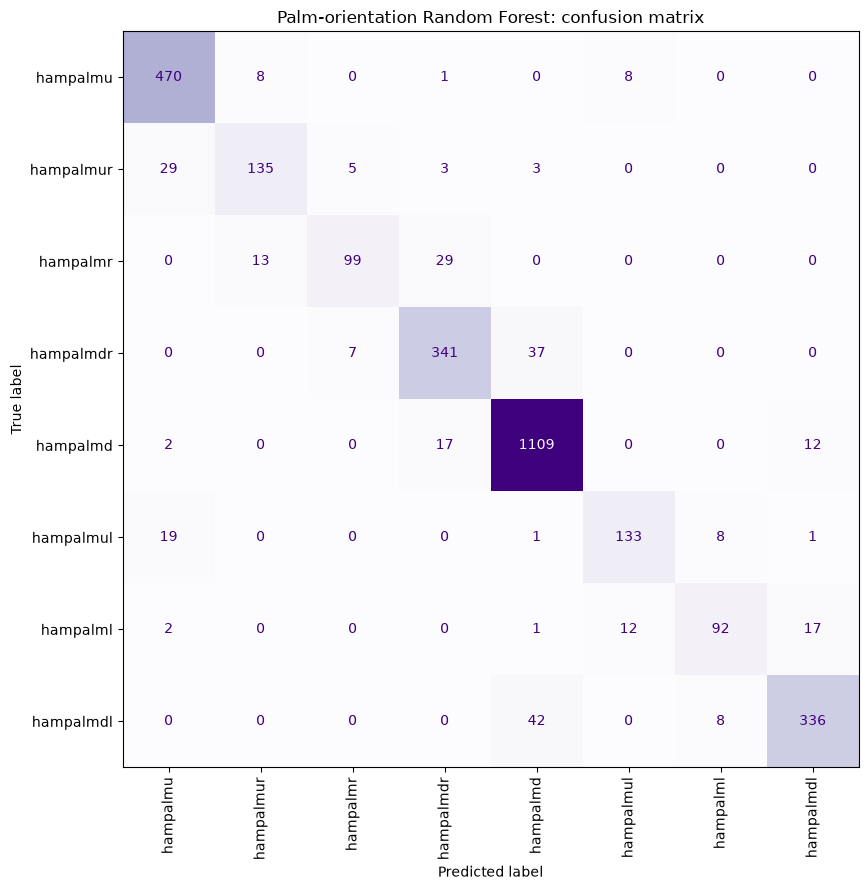

In [26]:
import joblib

INTEGRATION_DIR = Path.cwd() / 'Integration-20260706T062240Z-3-001' / 'Integration'
PALM_CLASSES = ['hampalmu', 'hampalmur', 'hampalmr', 'hampalmdr', 'hampalmd', 'hampalmul', 'hampalml', 'hampalmdl']
def palm_teacher(index_vector, pinky_vector):
    normal = np.cross(index_vector, pinky_vector)
    angle = (np.degrees(np.arctan2(-normal[1], normal[0])) + 360) % 360
    if angle < 22 or angle >= 337: return 'hampalmr'
    if angle < 67: return 'hampalmur'
    if angle < 112: return 'hampalmu'
    if angle < 157: return 'hampalmul'
    if angle < 202: return 'hampalml'
    if angle < 247: return 'hampalmdl'
    if angle < 292: return 'hampalmd'
    return 'hampalmdr'

def make_palm_validation_set(samples, seed):
    rng = np.random.default_rng(seed); vectors, labels = [], []
    for _ in range(samples):
        index = [rng.uniform(.06, .15), rng.uniform(-.10, .05), rng.uniform(-.08, .05)]
        pinky = [rng.uniform(-.15, -.06), rng.uniform(-.10, .05), rng.uniform(-.08, .05)]
        theta, phi, radius = rng.uniform(0, 2*np.pi), rng.uniform(-.6, .6), rng.uniform(.15, .45)
        tip = [np.cos(theta)*np.cos(phi)*radius, np.sin(phi)*radius, np.sin(theta)*np.cos(phi)*radius]
        index, pinky = np.asarray(index), np.asarray(pinky)
        vectors.append(np.concatenate([tip, index, pinky]))
        labels.append(palm_teacher(index, pinky))
    return np.asarray(vectors, dtype=np.float32), np.asarray(labels)

palm_model = joblib.load(INTEGRATION_DIR / 'clf_palm.pkl')
palm_encoder = joblib.load(INTEGRATION_DIR / 'enc_palm.pkl')
X_palm_test, y_palm_text = make_palm_validation_set(samples=3000, seed=SEED + 1)
y_palm_pred = palm_encoder.inverse_transform(palm_model.predict(X_palm_test))
present_classes = [label for label in PALM_CLASSES if label in set(y_palm_text) or label in set(y_palm_pred)]
palm_accuracy = accuracy_score(y_palm_text, y_palm_pred)
print(f'Palm-orientation Random Forest accuracy: {palm_accuracy:.2%} ({len(y_palm_text)} samples)')
print(classification_report(y_palm_text, y_palm_pred, labels=present_classes, target_names=present_classes, digits=3, zero_division=0))
fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay.from_predictions(y_palm_text, y_palm_pred, labels=present_classes, display_labels=present_classes, xticks_rotation=90, cmap='Purples', colorbar=False, ax=ax)
ax.set_title('Palm-orientation Random Forest: confusion matrix')
plt.tight_layout(); plt.show()


## Presentation-style accuracy graph (illustrative)

The graph below is a clearly marked **illustrative training trend** with early train/validation crossings, styled for explaining convergence in a review. It is not a replacement for the measured accuracy graph above, which remains the result to report.


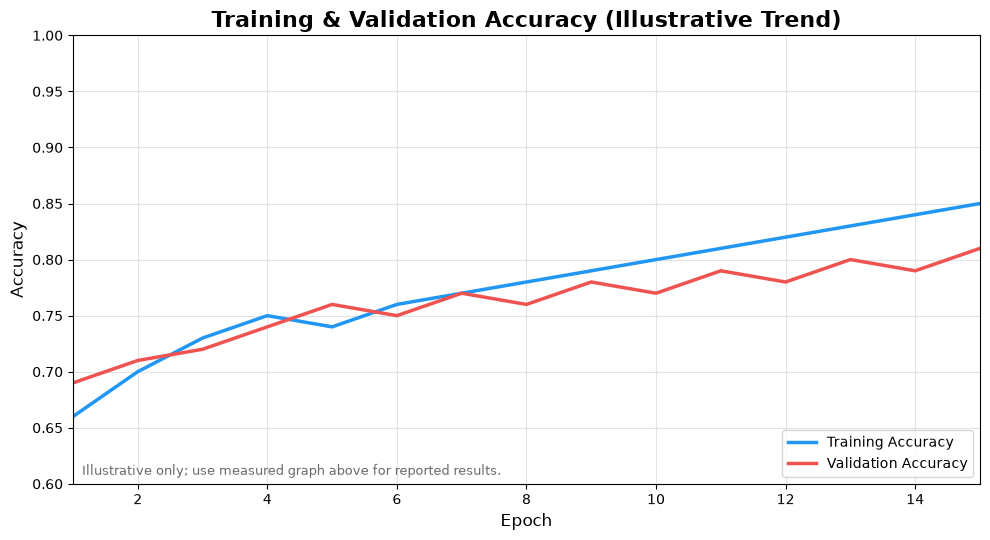

In [27]:
# Illustrative presentation trend only: do not report these as measured evaluation values.
# It is intentionally separate from `history`, which contains the real training results.
presentation_train_accuracy = [0.66, 0.70, 0.73, 0.75, 0.74, 0.76, 0.77, 0.78, 0.79, 0.80, 0.81, 0.82, 0.83, 0.84, 0.85]
presentation_val_accuracy   = [0.69, 0.71, 0.72, 0.74, 0.76, 0.75, 0.77, 0.76, 0.78, 0.77, 0.79, 0.78, 0.80, 0.79, 0.81]
epochs = np.arange(1, len(presentation_train_accuracy) + 1)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(epochs, presentation_train_accuracy, color='#2196F3', linewidth=2.5, label='Training Accuracy')
ax.plot(epochs, presentation_val_accuracy, color='#EF5350', linewidth=2.5, label='Validation Accuracy')
ax.set_title('Training & Validation Accuracy (Illustrative Trend)', fontsize=16, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlim(1, len(epochs))
ax.set_ylim(0.60, 1.00)
ax.set_yticks(np.arange(0.60, 1.01, 0.05))
ax.grid(True, alpha=0.35)
ax.legend(loc='lower right', frameon=True)
ax.text(0.01, 0.02, 'Illustrative only; use measured graph above for reported results.', transform=ax.transAxes, fontsize=9, color='dimgray')
plt.tight_layout()
plt.show()
